In [1]:
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-trainval', dataroot='/data/Pcmaploc/data/Nuscenes', verbose=True)

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 16.141 seconds.
Reverse indexing ...
Done reverse indexing in 4.6 seconds.


In [1]:

from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-mini', dataroot='/data/Pcmaploc/data/Nuscenes', verbose=True)


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.227 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [2]:
from nuscenes.nuscenes import NuScenes

# Initialize the nuScenes object
nusc = NuScenes(version='v1.0-trainval', dataroot='/data/Pcmaploc/data/Nuscenes', verbose=True)

# Iterate through all scenes
for scene in nusc.scene:
    # Get the first sample token in the scene
    first_sample_token = scene['first_sample_token']
    first_sample = nusc.get('sample', first_sample_token)
    
    # Get the first sample's ego_pose (translation)
    first_sample_data_token = first_sample['data']['LIDAR_TOP']
    sample_data = nusc.get('sample_data', first_sample_data_token)
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    
    # Extract and print the translation
    translation = ego_pose['translation']
    print(f"Scene: {scene['name']}, Origin Translation: {translation}")


Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 16.208 seconds.
Reverse indexing ...
Done reverse indexing in 4.7 seconds.
Scene: scene-0001, Origin Translation: [1010.1328353833223, 610.8111652918716, 0.0]
Scene: scene-0002, Origin Translation: [390.50662393327957, 1100.2516852821325, 0.0]
Scene: scene-0003, Origin Translation: [249.89610931430778, 917.5522573162784, 0.0]
Scene: scene-0004, Origin Translation: [357.39309935994675, 1072.799825649043, 0.0]
Scene: scene-0005, Origin Translation: [486.9132008159761, 1359.2021818539076, 0.0]
Scene: scene-0006, Origin Translation: [683.1729082160793, 1470.355907348241, 0.0]
Scene: scene-0007, Origin Translation: [893.6694309808445, 1568.2111181785294, 0.0]
Scene: scene-0008, Origin Translation: [852.7883802515286, 1652.293697

In [3]:



map_first_translation = {}

# 遍历所有 scene
for scene in nusc.scene:
    # 获取 scene 所属的日志信息
    log = nusc.get('log', scene['log_token'])
    map_name = log['location']  # 地图名称
    
    # 如果该地图已经记录过第一帧，跳过
    if map_name in map_first_translation:
        continue
    
    # 获取该 scene 的第一帧
    first_sample_token = scene['first_sample_token']
    first_sample = nusc.get('sample', first_sample_token)
    
    # 获取 LIDAR_TOP 数据并提取 ego_pose
    first_sample_data_token = first_sample['data']['LIDAR_TOP']
    sample_data = nusc.get('sample_data', first_sample_data_token)
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    
    # 存储该地图的第一帧 translation
    map_first_translation[map_name] = ego_pose['translation']

# 输出结果
for map_name, translation in map_first_translation.items():
    print(f"Map: {map_name}, First Frame Translation: {translation}")


Map: singapore-onenorth, First Frame Translation: [1010.1328353833223, 610.8111652918716, 0.0]
Map: boston-seaport, First Frame Translation: [2265.2343452437476, 793.9135686537878, 0.0]
Map: singapore-queenstown, First Frame Translation: [541.1698022106386, 1739.6315967318833, 0.0]
Map: singapore-hollandvillage, First Frame Translation: [605.0912446870816, 1991.4760606579857, 0.0]


In [4]:
for scene in nusc.scene:
    # 获取 scene 所属的日志信息
    log = nusc.get('log', scene['log_token'])
    print(log)
    break

{'token': '6b6513e6c8384cec88775cae30b78c0e', 'logfile': 'n015-2018-07-18-11-07-57+0800', 'vehicle': 'n015', 'date_captured': '2018-07-18', 'location': 'singapore-onenorth', 'map_token': '53992ee3023e5494b90c316c183be829'}


#### pc vis example

Loading NuScenes tables for version v1.0-trainval...


23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 17.705 seconds.
Reverse indexing ...
Done reverse indexing in 4.7 seconds.


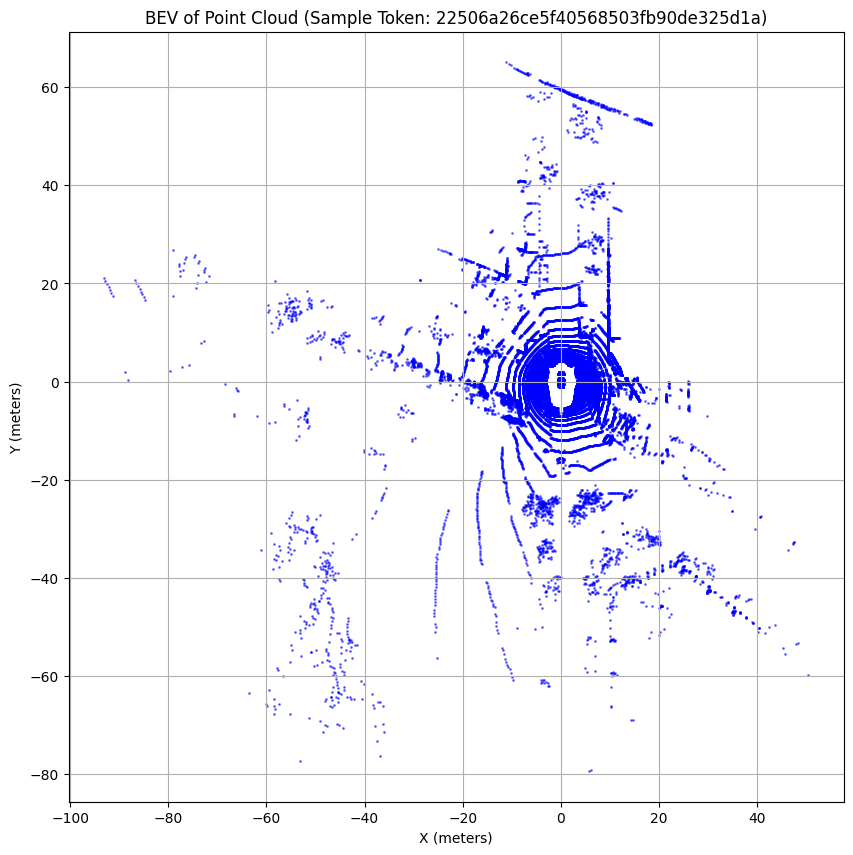

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

# 初始化 NuScenes 数据集
nusc = NuScenes(version='v1.0-trainval', dataroot='/data/Pcmaploc/data/Nuscenes', verbose=True)

# 指定 sample token
sample_token = '22506a26ce5f40568503fb90de325d1a'

# 获取 sample 数据
sample = nusc.get('sample', sample_token)

# 获取 LIDAR_TOP 的 sample_data token
lidar_token = sample['data']['LIDAR_TOP']

# 获取 LIDAR_TOP 的 sample_data 信息
sample_data = nusc.get('sample_data', lidar_token)

# 加载点云文件
lidar_filepath = nusc.get_sample_data_path(lidar_token)
point_cloud = LidarPointCloud.from_file(lidar_filepath)

# 获取 ego_pose（车辆位姿）
ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
translation = np.array(ego_pose['translation'])  # 平移向量
rotation = Quaternion(ego_pose['rotation']).rotation_matrix  # 旋转矩阵

# 转换点云到全局坐标系
points = point_cloud.points[:3, :]  # 提取点云的 x, y, z
# points_global = rotation @ points + translation.reshape(3, 1)  # 应用旋转和平移

# 提取 BEV（只保留 x, y）
# points_bev = points_global[:2, :]  # x, y 平面

# 可视化 BEV
plt.figure(figsize=(10, 10))
plt.scatter(points[0, :], points[1, :], s=1, c='blue', alpha=0.5)
plt.title(f'BEV of Point Cloud (Sample Token: {sample_token})')
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.axis('equal')
plt.grid(True)
plt.show()
